# Creating a Master Bad Pixel File


**Author: Dave Strickland**

**Version: 0.5.2-beta1**

This notebook illustrates 

1. how to generate a master bad pixel files given a master dark. The master bad pixel file is normally used as part of the calibration process (e.g. `ApCalibrate` or `ap_calibrate.py` from the command line), but can also be applied to calibrated files when you do not have the raw images. You must have a master dark frame, the longer the exposure time the better. Master bias files can be used, but will fail to pick up hot pixels where the charge increases with time.
2. How to generate a master dark given a set of darks.

The python environment used corresponds to a `miniconda` or `mini-forge` environment `ap-env.yml`.

The example master darks used are iTelescope T24 calibration files. Note that these files are not provided with this package. However the notebook should work with your own files if you specify a valid fits-file containing directory at the prompt below.

The notebook demonstrates processing using existing master dark files in the first section, followed by generation of master calibration files from raw dark, bias and flat field files in a later section.

Although some `matplotlib` images of the dark and bad pixel files are shown, much of the by-hand checking is done using [SAOImage ds9](https://sites.google.com/cfa.harvard.edu/saoimageds9). (Which I highly recommend.) 

## Notebook environment setup

In [1]:
import os
import pathlib
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
import math
import subprocess
import shlex

from ccdproc import ImageFileCollection
from astropy.table import Table
from astropy import wcs
import astropy
from astropy.io import fits

import AstroPhotography as ap

In [2]:
def print_module_version(mod):
    """
    Convenience function to pretty-print Python module mod version.

    Arguments:
        mod {module} -- Imported Python module

    Returns:
        str -- module name and version
    """
    print(f"Using module {mod.__name__:30s}  version: {mod.__version__}")
    return

In [3]:
# Get Version information
print(f'Python version: {sys.version}')
print_module_version(np)
print_module_version(matplotlib)
print_module_version(astropy)
print_module_version(ap)

Python version: 3.10.13 | packaged by conda-forge | (main, Dec 23 2023, 15:36:39) [GCC 12.3.0]
Using module numpy                           version: 1.26.3
Using module matplotlib                      version: 3.8.2
Using module astropy                         version: 6.0.0
Using module AstroPhotography                version: 0.5.2


In [4]:
# Enable inline plotting for graphics
# %matplotlib inline
# Set default figure size to be larger
# this may only work in matplotlib 2.0+!
from IPython.core.interactiveshell import InteractiveShell
matplotlib.rcParams['figure.figsize'] = [10.0, 6.0]
# Enable multiple outputs from jupyter cells
InteractiveShell.ast_node_interactivity = "all"

# Processing from Master Dark Files

## What files do we have to work with?

Let us change the working directory from the location of this notebook to a directory holding some iTelescope dark files. In my case this is the most recent set of calibration data for [iTelescope T24](https://support.itelescope.net/support/solutions/articles/231907-telescope-24). Dark and bias handling for T24 and T31 are more complicated than most iTelescope telescopes as they require [Residual Bulk Image (RBI) flushing](https://www.gxccd.com/art?id=418&lang=409), but for the purposes of generating bad pixel files we can ignore the RBI issue.

**Note:** I have renamed the iTelescope files to replace whitespace characters with underscores.

In [5]:
default_path = '/old_lnx/home/dks/Downloads/iTelescopeScratch/calibration-library/T24/Raw/2021_DEC/'
print(f'Enter the full path to the directory containing the master dark calibration files, or return to accept {default_path}')
wdir = input('Dark file set path:').strip() or default_path
try:
    os.chdir(wdir.strip())
    print('Switched directory to ' + os.getcwd())
except:
    print(f'Error, os.chdir threw an exception changing to {wdir}')
    print('Check that the path you supplied is a valid filesystem path.')
    raise

Enter the full path to the directory containing the master dark calibration files, or return to accept /old_lnx/home/dks/Downloads/iTelescopeScratch/calibration-library/T24/Raw/2021_DEC/


Dark file set path: 


Switched directory to /old_lnx/home/dks/Downloads/iTelescopeScratch/calibration-library/T24/Raw/2021_DEC


We now want to select some files of different binning, temperature, and the greatest exposure time we can find.

Listing the fits files from the shell I get:
```bash
find . -name "*900s*"
./Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_1_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
./Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_2_1528x1528_Bin2x2_Temp-25C_ExpTime900s.fit
./Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_12_1528x1528_Bin2x2_Temp-25C_ExpTime900s.fit
./Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
./Darks/Master_Dark_12_1528x1528_Bin2x2_Temp-25C_ExpTime900s.fit
./Darks/Master_Dark_6_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
```

In this case we want the 900 second exposure files, so a valid pattern that picks up the original files is `Master_Dark*900s.fit*`

In [6]:
default_pattern = 'Master_Dark*900s.fit*'
print(f'Default file pattern for input files: {default_pattern}')
msg = 'Enter new input file pattern (or return to accept default pattern)'
file_pattern = input(msg).strip() or default_pattern
print(f'Using "{file_pattern}" as the input file pattern.')

Default file pattern for input files: Master_Dark*900s.fit*


Enter new input file pattern (or return to accept default pattern) 


Using "Master_Dark*900s.fit*" as the input file pattern.


In [7]:

p_dir = pathlib.Path(r'./')
flist = list(sorted(p_dir.rglob(file_pattern)))
print(f'{len(flist)} files match pattern "{file_pattern}" in current directory.')
for fpath in flist:
    print(f'  {fpath}')

7 files match pattern "Master_Dark*900s.fit*" in current directory.
  Darks/Master_Dark_12_1528x1528_Bin2x2_Temp-25C_ExpTime900s.fit
  Darks/Master_Dark_6_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
  Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
  Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_12_1528x1528_Bin2x2_Temp-25C_ExpTime900s.fit
  Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_1_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
  Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_2_1528x1528_Bin2x2_Temp-25C_ExpTime900s.fit
  Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


In [8]:
# Look at the files in ds9. Note the annoying spaces cause trouble...
show_in_ds9=False

if show_in_ds9:
    import shutil
    if shutil.which("ds9") is not None:
        print('Calling shell to execute ds9...')
        !ds9 -cmap viridis -asinh -scale mode 99.5 -zoom 0.125 $(find . -name "$default_pattern" | xargs)
    else:
        print('No ds9 was found in your $PATH')

### Command line usage

#### Bad pixel file

To create the initial bad pixel file we could use `ap_find_badpix.py` on the command line, or the class `ApFindBadPixels`. Based on the `ds9` images I'll just use the `Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit` file.

```bash
ln -s Darks_RBI_flood_5_x_5sec/Darks/Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
python3 ~/git/AstroPhotography/AstroPhotography/scripts/ap_find_badpix.py -l DEBUG \
    Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit \
    Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
```

We can compare the original master dark to the bad pixel file:

Input data 0.5th percentile = 1735.5000, 99.5th percentile = 1889.5000
Applying asinh stretch between 1735.5000 and 1889.5000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)


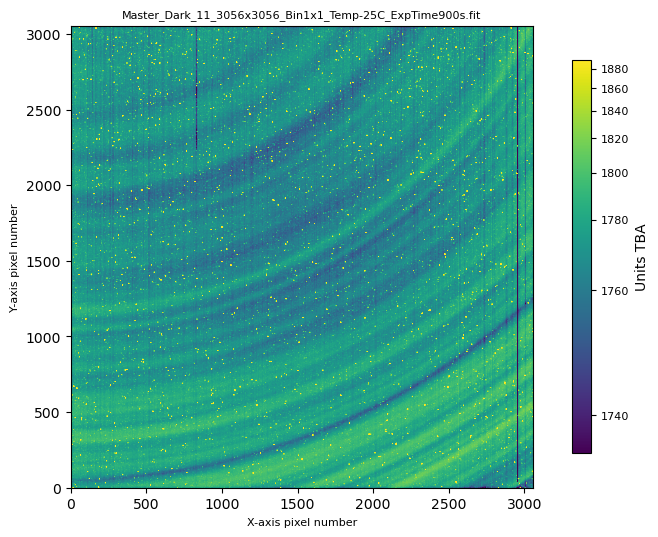

In [9]:
fname1 = 'Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit'
ap.util.load_image_and_plot(fname1, 0, usewcs=False)

In [10]:
masterdark = 'Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit'
badpixfile = masterdark.replace('Dark', 'Badpix')
print(f'For master dark {masterdark}, output bad pixel file is {badpixfile}')

# Have not got a file yet
userbadpix = None

# Defaults, don't have to actually use these
loglevel = 'INFO'
sigma    = 4.0
mkbadpix = ap.ApFindBadPixels(masterdark, sigma, loglevel)
        
if userbadpix is not None:
    mkbadpix.add_user_badpix(userbadpix)
        
# Write final bad pixels mask.
mkbadpix.write_mask(badpixfile)

2024-10-03 20:57:24,306 | ApFindBadPixels | INFO | Loading extension 0 of FITS file Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


For master dark Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit, output bad pixel file is Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


2024-10-03 20:57:25,351 | ApFindBadPixels | INFO | Good pixels have values between 1617.50 and 1723.50 ADU.
2024-10-03 20:57:25,368 | ApFindBadPixels | INFO | Out of 9339136 pixels, 85015 are bad (0.9103%).
2024-10-03 20:57:25,376 | ApFindBadPixels | INFO | Wrote bad pixel mask to Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


Input data 0.5th percentile = 0.0000, 99.5th percentile = 1.0000
Applying asinh stretch between 0.0000 and 1.0000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)


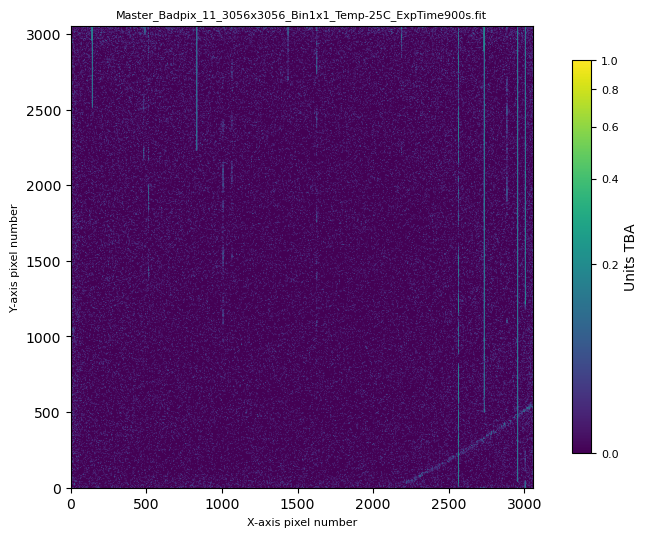

In [11]:
ap.util.load_image_and_plot(badpixfile, 0, usewcs=False, vmin=0, vmax=1)

Lets zoom in on a smaller region of the files... For example the lower right hand corner

Input data 0.5th percentile = 1735.5000, 99.5th percentile = 1889.5000
Applying asinh stretch between 1735.5000 and 1889.5000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]


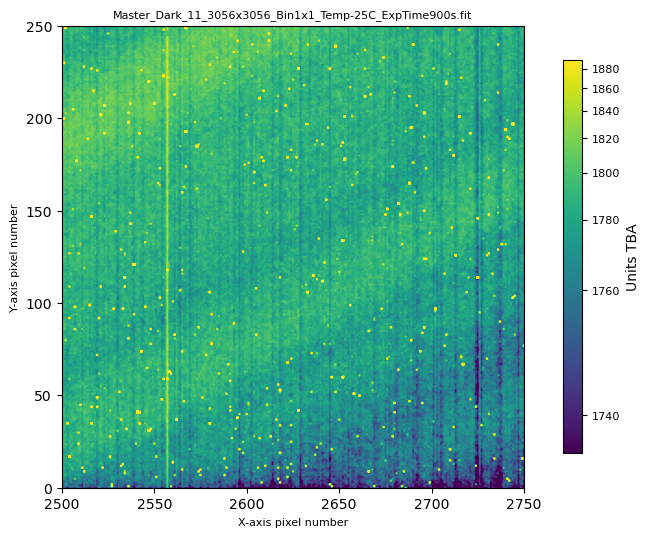

In [12]:
xreg = (2500, 2750)
yreg = (0, 250)
ap.util.load_image_and_plot(masterdark, 0, usewcs=False, vmin=None, vmax=None, xaxlim=xreg, yaxlim=yreg, verbose=True)

Input data 0.5th percentile = 0.0000, 99.5th percentile = 1.0000
Applying asinh stretch between 0.0000 and 1.0000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]


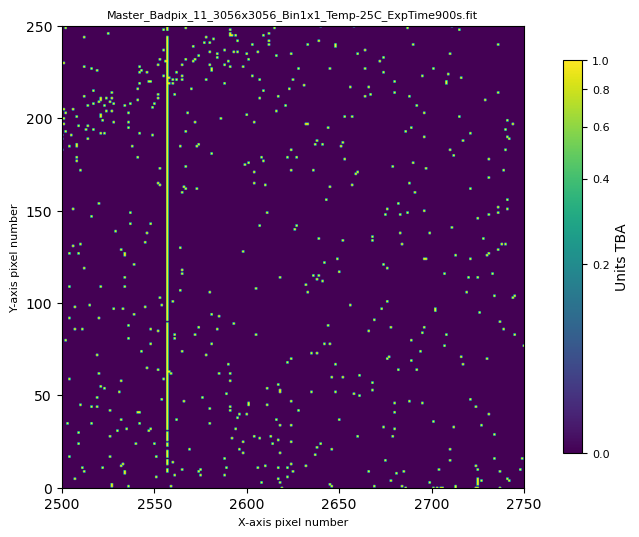

In [13]:
ap.util.load_image_and_plot(badpixfile, 0, usewcs=False, vmin=None, vmax=None, xaxlim=xreg, yaxlim=yreg, verbose=True)

The tool appears to have done a good job at finding individual bad pixels, but there are columns where every pixel is either hot or cold that it either hasn't completely detected (e.g. the column near X=2560) or completely missed (the cold columns between X=2700 and X=2750).

#### Bad columns, rows, rectangles etc 

To get a first go at detecting these bad columns (or rows) you should normally follow every use of `ApFindBadPixels` with `ApAutoBadcols` (or `ap_auto_badcol.py` on the command line). This will generate a YaML file that can then be combined with the bad pixels to generate an updated and improved bad pixel file. The tool also has options to generate CSV files of the along-column and along-row statistics, and generate a plot.

The YaML file can then be combined with bad pixel detection...

```bash
# example of minimal run, generating only the yaml file (and not over-writing it if it exists)
python3 ~/git/AstroPhotography/AstroPhotography/scripts/ap_auto_badcol.py -l DEBUG Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit \
    -user_badcol_file=t24_user_badpixels_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.yml 


# doing every thing
python3 ~/git/AstroPhotography/AstroPhotography/scripts/ap_auto_badcol.py -l DEBUG Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit \
    --column_stats=colstats.csv --row_stats=rowstats.csv \
    --user_badcol_file=t24_user_badpixels_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.yml --overwrite \
    --plot_stats=t24_badcolplot.png


# update the master bad pixel file
python3 ~/git/AstroPhotography/AstroPhotography/scripts/ap_find_badpix.py -l DEBUG \
    Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit \
    Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit \
    --user_badpix t24_user_badpixels_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.yml
```

Or you can run the commands within python...

2024-10-03 20:57:26,317 | ApAutoBadcols | INFO | Loading extension 0 of FITS file Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
2024-10-03 20:57:26,969 | ApAutoBadcols | INFO | Found 46 bad columns out of 3056 columns.
/home/dks/git/AstroPhotography/AstroPhotography/core/ApAutoBadcols.py:283: RuntimeWarning: invalid value encountered in divide
  nsigma_from_mean      = np.abs(median_array - sldng_mean) / sldng_std
2024-10-03 20:57:27,377 | ApAutoBadcols | INFO | Found 0 bad rows out of 3056 rows.
2024-10-03 20:57:27,380 | ApAutoBadcols | INFO | Wrote bad column/row YaML file to t24_user_badpixels_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.yml


Bad columns (46): [  22   92  108  301  480  572  609  789  943  949 1002 1003 1009 1062
 1183 1237 1274 1280 1331 1367 1378 1568 1622 1721 1732 1752 1791 1829
 1836 1918 1950 2058 2062 2158 2406 2449 2645 2727 2768 2877 2948 2997
 2998 3010 3036 3050]
No bad rows...


2024-10-03 20:57:27,877 | ApAutoBadcols | INFO | Column/row statistics info plot written to t24_badcolplot.png


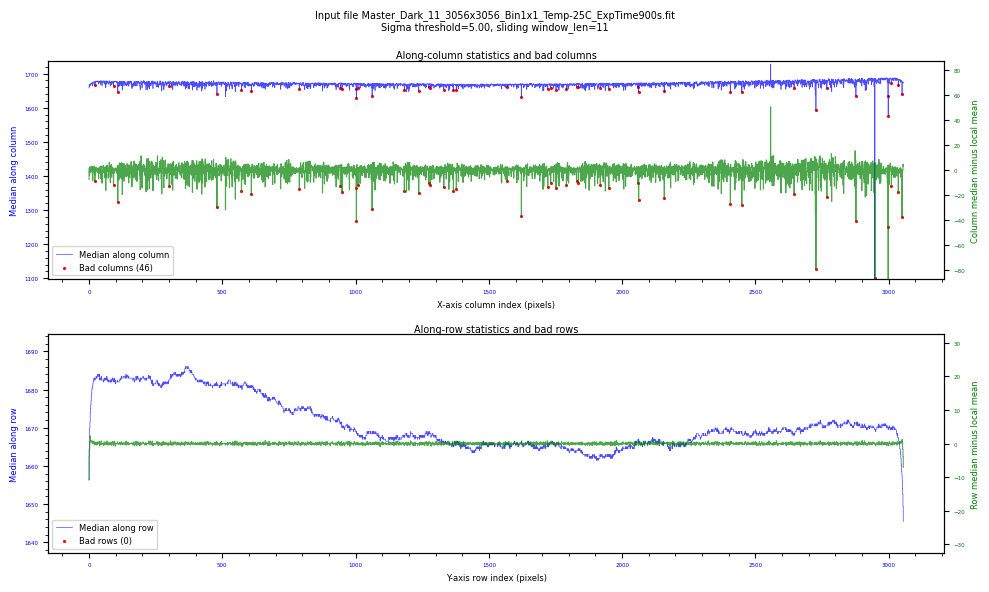

In [14]:
# Create an instance of the ApAutoBadcols.
auto_badcols = ap.ApAutoBadcols('INFO')

# Process the masterdark
sigma = 5.0  # default, you don't have to specify them if you
window = 11  # want the defaults
badcols, badrows = auto_badcols.process_fits(masterdark, 
    sigma, 
    window)

badcolfile = 't24_user_badpixels_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.yml'
overwrite  = True
plotstats  = 't24_badcolplot.png'
colstats   = None
rowstats   = None

# We don't actually have to use the badcols and badrows here unless we want to
if badcols is not None:
    print(f'Bad columns ({len(badcols)}): {badcols}')
else:
    print('No bad columns...')
if badrows is not None:
    print(f'Bad row ({len(badrows)}): {badrows}')
else:
    print('No bad rows...')

if badcolfile is not None:
    auto_badcols.write_badcols_file(badcolfile, overwrite)
    
if plotstats is not None:
    auto_badcols.generate_stats_plot(plotstats)
    
if (colstats is not None) or (rowstats is not None):
    auto_badcols.write_stats(colstats, rowstats)

In [15]:
!cat $badcolfile

---
# Column statistics file generated by AstroPhotography.core.ApAutoBadcols version 0.5.2
# Generated from Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
# Processing parameters: badness sigma threshold=5.00, sliding window_len=11
#
# This is a YaML file that consists of three named sections:
# - bad_columns: Entries are column indices of any entire column 
#   to be marked bad.
# - bad_rows: Entries are row indices of any entire row to be marked bad.
# - bad_rectangles: Entries are lists of the coordinates 
#   [row_start, row_end, col_start, col_end] of the rectangle to be marked
#   bad.
#
# Note that these are:
# 0. You need separate user-defined bad pixel files for different chip
#    binnings!
# 1. 1-based indices, e.g. as reported by ds9, not python/C style 
#    0-based indices. So the index of the second column in the image
#    is 2, not 1.
# 2. Inclusive ranges (mathematical notation "[]"), so the rectangle 
#    2,3,60,62 is a 2 row, 3 column region that include

In [16]:
# Now incorporate that back into generating the master bad pixel file...
masterdark = 'Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit'
badpixfile = masterdark.replace('Dark', 'Badpix')
print(f'For master dark {masterdark}, output bad pixel file is {badpixfile}')

# Have not got a file yet
userbadpix = badcolfile

# Defaults, don't have to actually use these
loglevel = 'INFO'
sigma    = 4.0
mkbadpix = ap.ApFindBadPixels(masterdark, sigma, loglevel)
        
if userbadpix is not None:
    mkbadpix.add_user_badpix(userbadpix)
        
# Write final bad pixels mask.
mkbadpix.write_mask(badpixfile)

2024-10-03 20:57:28,204 | ApFindBadPixels | INFO | Loading extension 0 of FITS file Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


For master dark Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit, output bad pixel file is Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


2024-10-03 20:57:29,240 | ApFindBadPixels | INFO | Good pixels have values between 1617.50 and 1723.50 ADU.
2024-10-03 20:57:29,256 | ApFindBadPixels | INFO | Out of 9339136 pixels, 85015 are bad (0.9103%).
2024-10-03 20:57:29,259 | ApFindBadPixels | INFO | Processing user-defined bad pixels from t24_user_badpixels_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.yml
2024-10-03 20:57:29,261 | ApFindBadPixels | INFO | Adding 46 bad columns to 3056 row, 3056 column mask.
2024-10-03 20:57:29,276 | ApFindBadPixels | INFO | Wrote bad pixel mask to Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


Input data 0.5th percentile = 1735.5000, 99.5th percentile = 1889.5000
Applying asinh stretch between 1735.5000 and 1889.5000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]
Input data 0.5th percentile = 0.0000, 99.5th percentile = 2.0000
Applying asinh stretch between 0.0000 and 2.0000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]


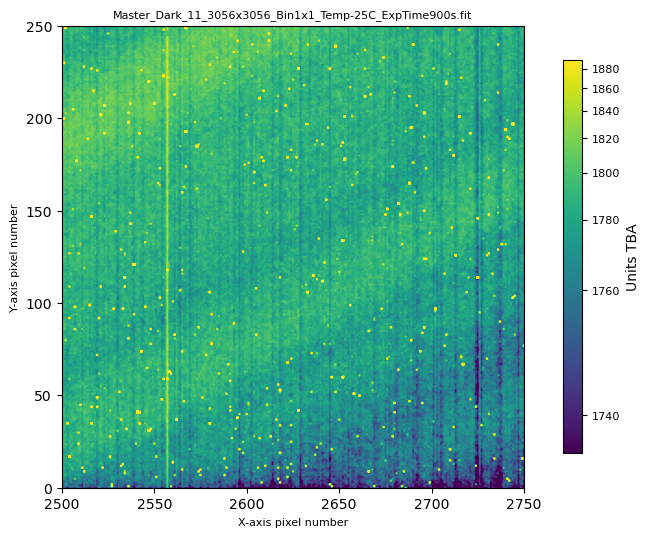

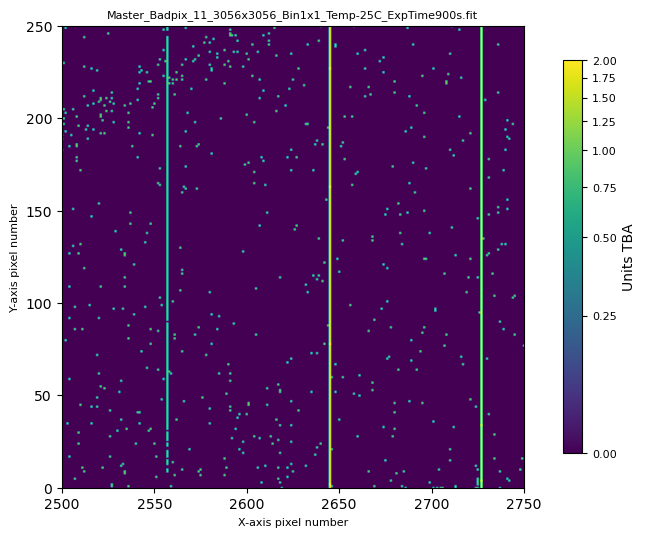

In [17]:
# Now load and plot the updated badpixel file ...
xreg = (2500, 2750)
yreg = (0, 250)
ap.util.load_image_and_plot(masterdark, 0, usewcs=False, vmin=None, vmax=None, xaxlim=xreg, yaxlim=yreg, verbose=True)
ap.util.load_image_and_plot(badpixfile, 0, usewcs=False, vmin=None, vmax=None, xaxlim=xreg, yaxlim=yreg, verbose=True)

Note that two new bad columns were added. In the bad pixel file user-specified bad pixels/columns/rows are given the dtata quality flag 2, to contrast with the pixels found by ApFindBadPixels.

What about the likely bad columns at column numbers around 2555 and around 2735? Generation of the column statistics CSv file shows that...
```
# Column statistics file generated by AstroPhotography.core.ApAutoBadcols version 0.5.2
# Generated from Master_Dark_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit
# Processing parameters: badness sigma threshold=5.00, sliding window_len=11
# col,    median,local_mean, local_std,    nsigma,isbad
00000,   1658.00,   1665.25,      4.14,      1.75,    0
00001,   1667.00,   1665.50,      3.88,      0.39,    0
00002,   1662.00,   1666.06,      3.92,      1.04,    0
...
02554,   1663.00,   1672.20,      5.94,      1.55,    0
02555,   1663.50,   1671.70,      5.77,      1.42,    0
02556,   1677.50,   1670.65,      6.52,      1.05,    0
02557,   1728.00,   1677.27,     17.35,      2.92,    0
02558,   1676.50,   1670.25,      7.73,      0.81,    0
02559,   1670.50,   1668.15,      7.92,      0.30,    0
02560,   1671.50,   1669.80,      8.38,      0.20,    0
...
02726,   1681.50,   1671.45,     14.25,      0.71,    0
02727,   1592.50,   1671.25,     14.20,      5.55,    1
02728,   1670.50,   1670.75,     13.86,      0.02,    0
02729,   1679.50,   1671.15,     13.98,      0.60,    0
02730,   1679.50,   1676.72,      4.49,      0.62,    0
02731,   1682.00,   1675.90,      4.92,      1.24,    0
02732,   1674.00,   1673.60,      6.79,      0.06,    0
02733,   1678.00,   1672.95,      6.79,      0.74,    0
02734,   1677.00,   1674.09,      7.31,      0.40,    0
02735,   1668.50,   1674.41,      7.61,      0.78,    0
02736,   1668.50,   1674.27,      7.53,      0.77,    0
02737,   1658.50,   1674.45,      7.73,      2.06,    0
02738,   1666.50,   1674.68,      7.75,      1.06,    0
02739,   1683.00,   1674.68,      7.75,      1.07,    0
02740,   1683.00,   1673.14,      8.76,      1.13,    0
02741,   1678.00,   1673.59,      8.64,      0.51,    0
02742,   1684.00,   1672.55,      9.81,      1.17,    0
02743,   1676.50,   1674.32,      8.82,      0.25,    0
```

...they're around 2.9 and 2.0 sigma from the local mean. Not enough to automatically trigger inclusion in the list with the default settings of 5 sigma deviations within a 11 pixel sliding average. *But* there is nothing stopping you from adding them to the user defined bad column file yourself and rerunning `ApFindBadPixels` with the YaML file.

**Tip:** I typically only include user-defined bad columns/rows, pixels, or regions if I process real data correcting for the existing bad pixel FITS file and I see artifacts. Then I would update the YaML file, rebuild the master bad pixel file, and reprocess the data. In practice this can take several iterations to work through all the bad regions in order of decreasing significance.



In [18]:
# Finally print out the name of the master bad pixel file including the full path
p = pathlib.Path(badpixfile)
print(f'Absolute path to bad pixel file: {str(p.absolute())}')

Absolute path to bad pixel file: /old_lnx/home/dks/Downloads/iTelescopeScratch/calibration-library/T24/Raw/2021_DEC/Master_Badpix_11_3056x3056_Bin1x1_Temp-25C_ExpTime900s.fit


# Processing from Individual Dark Files

In this example we combine a set of 10 dark files into a master dark file, then create a master bad pixel file from that. These are 300 second dark files taken from iTelescope T24 with the dome closed, just after dawn on 2024-10-01.

If you have a directory with a set of dark files you should enter the path to it when prompted.

In [19]:
default_path = '/old_lnx/home/dks/Downloads/iTelescopeScratch/T24/CALIBRATION/Dark/Bin1/300'
print(f'Enter the full path to the directory containing the raw dark calibration files, or return to accept {default_path}')
wdir = input('Dark file set path:').strip() or default_path
try:
    os.chdir(wdir.strip())
    print('Switched directory to ' + os.getcwd())
except:
    print(f'Error, os.chdir threw an exception changing to {wdir}')
    print('Check that the path you supplied is a valid filesystem path.')
    raise

Enter the full path to the directory containing the raw dark calibration files, or return to accept /old_lnx/home/dks/Downloads/iTelescopeScratch/T24/CALIBRATION/Dark/Bin1/300


Dark file set path: 


Switched directory to /old_lnx/home/dks/Downloads/iTelescopeScratch/T24/CALIBRATION/Dark/Bin1/300


In [20]:
default_pattern = 'T24*-Dark-*.fit*'
print(f'Default file pattern for input files: {default_pattern}')
msg = 'Enter new input file pattern (or return to accept default pattern)'
file_pattern = input(msg).strip() or default_pattern
print(f'Using "{file_pattern}" as the input file pattern.')

Default file pattern for input files: T24*-Dark-*.fit*


Enter new input file pattern (or return to accept default pattern) 


Using "T24*-Dark-*.fit*" as the input file pattern.


In [21]:
p_dir = pathlib.Path(r'./')
flist = list(sorted(p_dir.rglob(file_pattern)))
print(f'{len(flist)} files match pattern "{file_pattern}" in current directory.')
for fpath in flist:
    print(f'  {fpath}')

10 files match pattern "T24*-Dark-*.fit*" in current directory.
  T24-davestrickland-Dark-300-LD20240930-LT065415-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT065926-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT070438-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT070949-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT071501-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT072012-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT072524-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT073035-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT073547-BIN1.fit
  T24-davestrickland-Dark-300-LD20240930-LT074059-BIN1.fit


In [22]:
# Create an instance of ApMasterCal
exclude_pattern = 'master*'
master_maker = ap.ApMasterCal(r'./', exclude_pattern=exclude_pattern, telescop='iTelescope 24', loglevel='DEBUG')

2024-10-03 20:57:31,750 | ApMasterCal | INFO | Looking for FITS files in ., excluding files matching the pattern "master*"
2024-10-03 20:57:31,770 | ApMasterCal | INFO | Found 10 FITS files matching the constraints.
2024-10-03 20:57:31,770 | ApMasterCal | DEBUG | For keyword date-obs there are 10 values: ['2024-10-01T13:54:18.03', '2024-10-01T14:41:02.41', '2024-10-01T14:15:04.26', '2024-10-01T14:04:41.13', '2024-10-01T14:30:38.53', '2024-10-01T14:09:52.60', '2024-10-01T13:59:29.55', '2024-10-01T14:25:27.45', '2024-10-01T14:35:50.66', '2024-10-01T14:20:15.87']
2024-10-03 20:57:31,771 | ApMasterCal | DEBUG | For keyword telescop there are 1 values: ['']
2024-10-03 20:57:31,771 | ApMasterCal | DEBUG | For keyword imagetyp there are 1 values: ['Dark Frame']
2024-10-03 20:57:31,771 | ApMasterCal | DEBUG | For keyword filter there are 1 values: [None]
2024-10-03 20:57:31,771 | ApMasterCal | DEBUG | For keyword exptime there are 1 values: [300.0]
2024-10-03 20:57:31,771 | ApMasterCal | DEBUG

In [23]:
# Run it
masterdark = 'master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits'
master_maker.make_master(masterdark)

2024-10-03 20:57:31,790 | ApMasterCal | DEBUG | About to combine 10 MASTER DARK files, method=average sigma_clip=True sig_clip_lothresh=5 sig_clip_hithresh=5 max_ram_bytes=5.000e+08.
INFO:astropy:splitting each image into 9 chunks to limit memory usage to 500000000.0 bytes.


INFO: splitting each image into 9 chunks to limit memory usage to 500000000.0 bytes. [ccdproc.combiner]


2024-10-03 20:57:37,739 | ApMasterCal | INFO | Wrote combined calibration file: master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


Input data 0.5th percentile = 1452.5000, 99.5th percentile = 1575.4000
Applying asinh stretch between 1452.5000 and 1575.4000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)


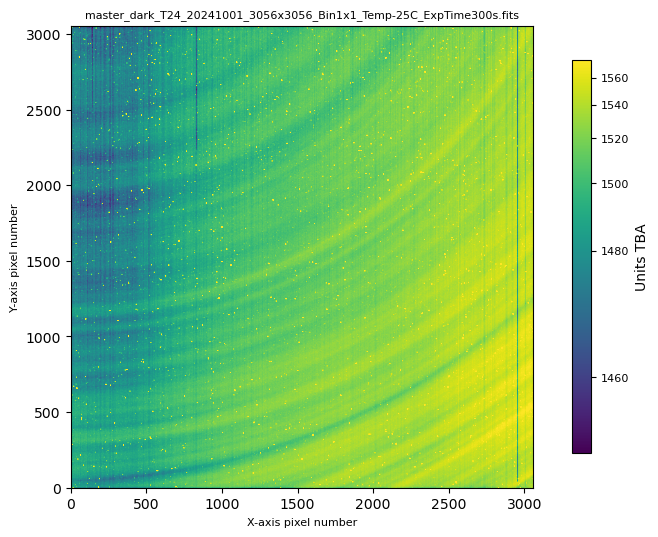

In [40]:
# Look at this file before proceding
ap.util.load_image_and_plot(masterdark, 0, usewcs=False)

In [42]:
badpixfile = masterdark.replace('dark', 'badpix')
print(f'For master dark {masterdark}, output bad pixel file is {badpixfile}')

# Have not got a file yet
userbadpix = None

# Defaults, don't have to actually use these
loglevel = 'INFO'
sigma    = 4.0
mkbadpix = ap.ApFindBadPixels(masterdark, sigma, loglevel)
        
if userbadpix is not None:
    mkbadpix.add_user_badpix(userbadpix)
        
# Write final bad pixels mask.
mkbadpix.write_mask(badpixfile)

2024-10-03 21:22:37,137 | ApFindBadPixels | INFO | Loading extension 0 of FITS file master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


For master dark master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits, output bad pixel file is master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


2024-10-03 21:22:38,145 | ApFindBadPixels | INFO | Good pixels have values between 1410.96 and 1611.44 ADU.
2024-10-03 21:22:38,165 | ApFindBadPixels | INFO | Out of 9339136 pixels, 24122 are bad (0.2583%).
2024-10-03 21:22:38,175 | ApFindBadPixels | INFO | Wrote bad pixel mask to master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


Input data 0.5th percentile = 0.0000, 99.5th percentile = 0.0000
Applying asinh stretch between 0.0000 and 1.0000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)


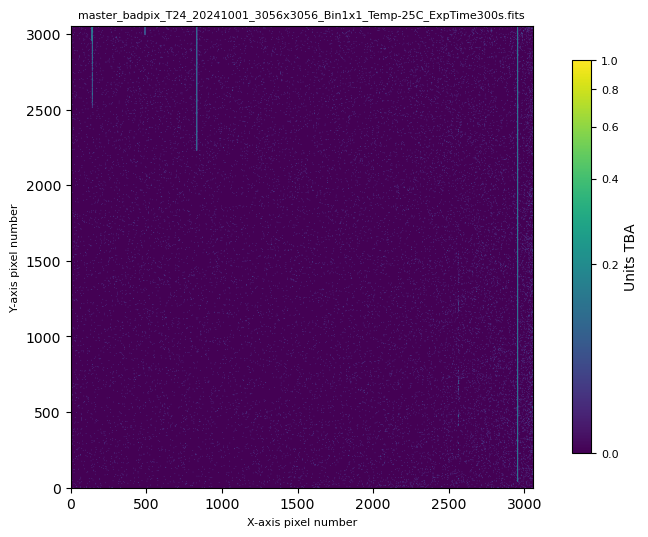

In [43]:
ap.util.load_image_and_plot(badpixfile, 0, usewcs=False, vmin=0, vmax=1)

Input data 0.5th percentile = 1452.5000, 99.5th percentile = 1575.4000
Applying asinh stretch between 1452.5000 and 1575.4000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]


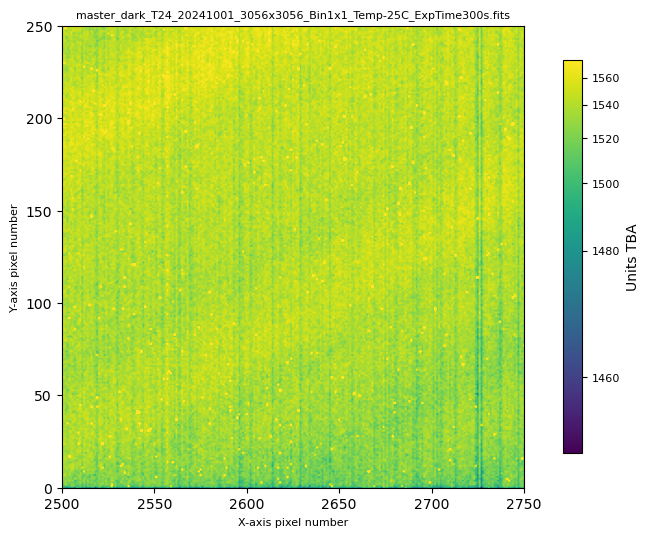

In [44]:
xreg = (2500, 2750)
yreg = (0, 250)
ap.util.load_image_and_plot(masterdark, 0, usewcs=False, vmin=None, vmax=None, xaxlim=xreg, yaxlim=yreg, verbose=True)

Input data 0.5th percentile = 0.0000, 99.5th percentile = 0.0000
Applying asinh stretch between 0.0000 and 2.0000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]


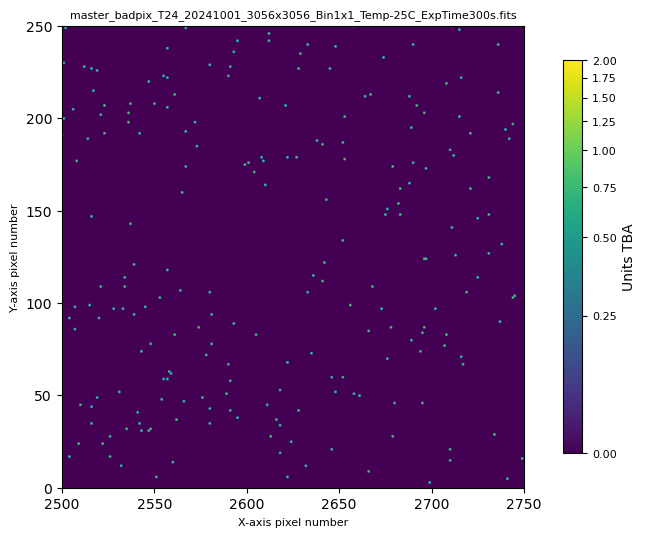

In [45]:
ap.util.load_image_and_plot(badpixfile, 0, usewcs=False, vmin=0, vmax=2, xaxlim=xreg, yaxlim=yreg, verbose=True)

2024-10-03 21:22:39,138 | ApAutoBadcols | INFO | Loading extension 0 of FITS file master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits
2024-10-03 21:22:39,630 | ApAutoBadcols | INFO | Found 54 bad columns out of 3056 columns.
2024-10-03 21:22:39,973 | ApAutoBadcols | INFO | Found 0 bad rows out of 3056 rows.
2024-10-03 21:22:39,976 | ApAutoBadcols | INFO | Wrote bad column/row YaML file to t24_user_badpixels_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.yml


Bad columns (54): [  14   63   92  240  301  480  572  609  719  789  876  943  949  977
 1002 1003 1062 1129 1183 1237 1274 1280 1286 1331 1367 1378 1568 1622
 1721 1732 1791 1836 1876 1897 1936 1950 2062 2158 2182 2344 2372 2406
 2557 2645 2727 2877 2948 2995 2997 2998 3010 3018 3036 3039]
No bad rows...


2024-10-03 21:22:40,471 | ApAutoBadcols | INFO | Column/row statistics info plot written to t24_20241001_badcolplot.png


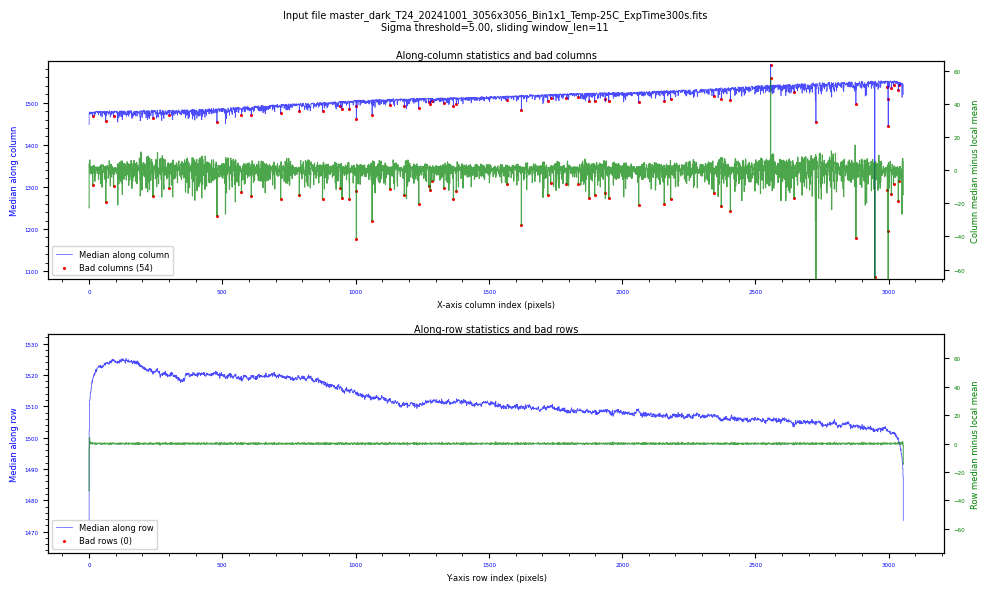

In [46]:
# Create an instance of the ApAutoBadcols.
auto_badcols = ap.ApAutoBadcols('INFO')

# Process the masterdark
sigma = 5.0  # default, you don't have to specify them if you
window = 11  # want the defaults
badcols, badrows = auto_badcols.process_fits(masterdark, 
    sigma, 
    window)

# remember the master dark is 'master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits'
badcolfile = 't24_user_badpixels_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.yml'
overwrite  = True
plotstats  = 't24_20241001_badcolplot.png'
colstats   = None
rowstats   = None

# We don't actually have to use the badcols and badrows here unless we want to
if badcols is not None:
    print(f'Bad columns ({len(badcols)}): {badcols}')
else:
    print('No bad columns...')
if badrows is not None:
    print(f'Bad row ({len(badrows)}): {badrows}')
else:
    print('No bad rows...')

if badcolfile is not None:
    auto_badcols.write_badcols_file(badcolfile, overwrite)
    
if plotstats is not None:
    auto_badcols.generate_stats_plot(plotstats)
    
if (colstats is not None) or (rowstats is not None):
    auto_badcols.write_stats(colstats, rowstats)

In [47]:
!cat $badcolfile

---
# Column statistics file generated by AstroPhotography.core.ApAutoBadcols version 0.5.2
# Generated from master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits
# Processing parameters: badness sigma threshold=5.00, sliding window_len=11
#
# This is a YaML file that consists of three named sections:
# - bad_columns: Entries are column indices of any entire column 
#   to be marked bad.
# - bad_rows: Entries are row indices of any entire row to be marked bad.
# - bad_rectangles: Entries are lists of the coordinates 
#   [row_start, row_end, col_start, col_end] of the rectangle to be marked
#   bad.
#
# Note that these are:
# 0. You need separate user-defined bad pixel files for different chip
#    binnings!
# 1. 1-based indices, e.g. as reported by ds9, not python/C style 
#    0-based indices. So the index of the second column in the image
#    is 2, not 1.
# 2. Inclusive ranges (mathematical notation "[]"), so the rectangle 
#    2,3,60,62 is a 2 row, 3 column region t

In [48]:
# Now incorporate that back into generating the master bad pixel file...
print(f'For master dark {masterdark}, output bad pixel file is {badpixfile}')

# Have not got a file yet
userbadpix = badcolfile

# Defaults, don't have to actually use these
loglevel = 'INFO'
sigma    = 4.0
mkbadpix = ap.ApFindBadPixels(masterdark, sigma, loglevel)
        
if userbadpix is not None:
    mkbadpix.add_user_badpix(userbadpix)
        
# Write final bad pixels mask.
mkbadpix.write_mask(badpixfile)

2024-10-03 21:22:40,794 | ApFindBadPixels | INFO | Loading extension 0 of FITS file master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


For master dark master_dark_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits, output bad pixel file is master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


2024-10-03 21:22:41,747 | ApFindBadPixels | INFO | Good pixels have values between 1410.96 and 1611.44 ADU.
2024-10-03 21:22:41,766 | ApFindBadPixels | INFO | Out of 9339136 pixels, 24122 are bad (0.2583%).
2024-10-03 21:22:41,768 | ApFindBadPixels | INFO | Processing user-defined bad pixels from t24_user_badpixels_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.yml
2024-10-03 21:22:41,771 | ApFindBadPixels | INFO | Adding 54 bad columns to 3056 row, 3056 column mask.
2024-10-03 21:22:41,782 | ApFindBadPixels | INFO | Wrote bad pixel mask to master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


Input data 0.5th percentile = 1452.5000, 99.5th percentile = 1575.4000
Applying asinh stretch between 1452.5000 and 1575.4000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]
Input data 0.5th percentile = 0.0000, 99.5th percentile = 2.0000
Applying asinh stretch between 0.0000 and 2.0000
Default X-axis limits: (-0.5, 3055.5)
Default Y-axis limits: (-0.5, 3055.5)
Setting X-axis limits to [2500, 2750]
Setting Y-axis limits to [0, 250]


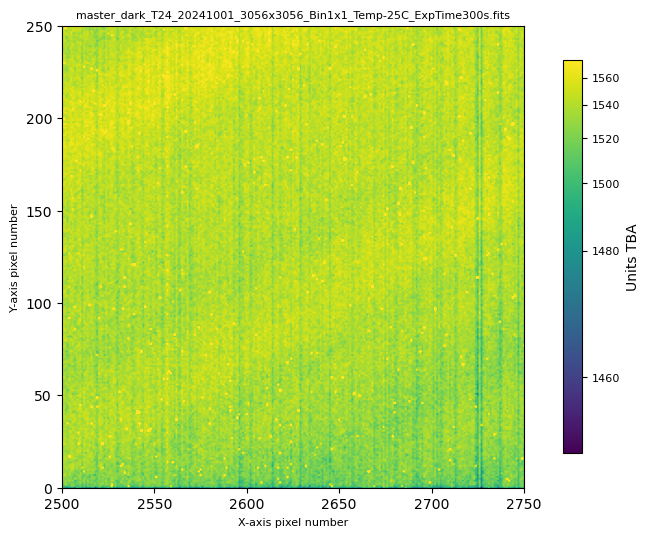

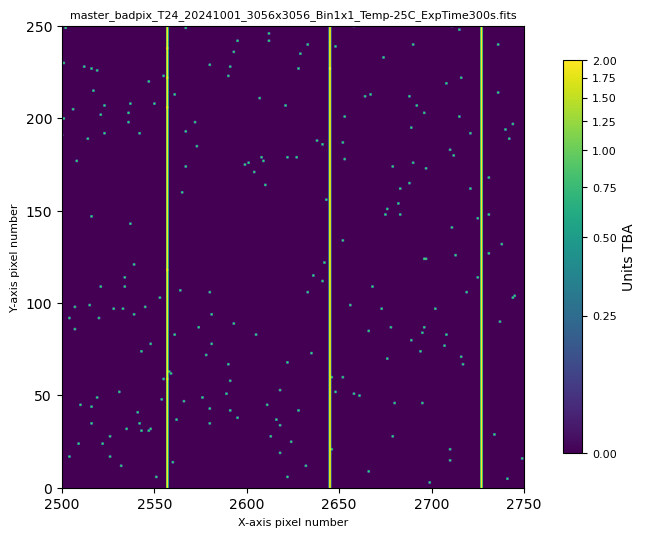

In [49]:
# Now load and plot the updated badpixel file ...
xreg = (2500, 2750)
yreg = (0, 250)
ap.util.load_image_and_plot(masterdark, 0, usewcs=False, vmin=None, vmax=None, xaxlim=xreg, yaxlim=yreg, verbose=True)
ap.util.load_image_and_plot(badpixfile, 0, usewcs=False, vmin=None, vmax=None, xaxlim=xreg, yaxlim=yreg, verbose=True)

In [50]:
# Finally print out the name of the master bad pixel file including the full path
p = pathlib.Path(badpixfile)
print(f'Absolute path to bad pixel file: {str(p.absolute())}')

Absolute path to bad pixel file: /old_lnx/home/dks/Downloads/iTelescopeScratch/T24/CALIBRATION/Dark/Bin1/300/master_badpix_T24_20241001_3056x3056_Bin1x1_Temp-25C_ExpTime300s.fits


# Versions and Changes

| Version | Date | Description |
|:--------|------|-------------|
| 0.5.2-beta1 | 2024-04-26 | Partial version includes use of master bad pixel file and auto badcols use |